In [3]:
import random
import time
import matplotlib.pyplot as plt


def merge(arr, left, mid, right):

    L = arr[left:mid + 1]
    R = arr[mid + 1:right + 1]

    i = 0
    j = 0
    k = left

    while i < len(L) and j < len(R):

        if L[i] <= R[j]:
            arr[k] = L[i]
            i += 1
        else:
            arr[k] = R[j]
            j += 1

        k += 1

    while i < len(L):
        arr[k] = L[i]
        i += 1
        k += 1

    while j < len(R):
        arr[k] = R[j]
        j += 1
        k += 1



def merge_sort(arr, left, right):

    if left < right:

        mid = (left + right) // 2

        merge_sort(arr, left, mid)
        merge_sort(arr, mid + 1, right)

        merge(arr, left, mid, right)



sizes = list(range(100, 10001, 500))

avg_times = []

runs = 20

for size in sizes:

    original = [
        random.randint(1, 100000)
        for _ in range(size)
    ]

    total_time = 0

    for _ in range(runs):


        arr = original.copy()

        start = time.perf_counter_ns()

        merge_sort(arr, 0, size - 1)

        end = time.perf_counter_ns()

        total_time += end - start

    avg_times.append(total_time / runs)


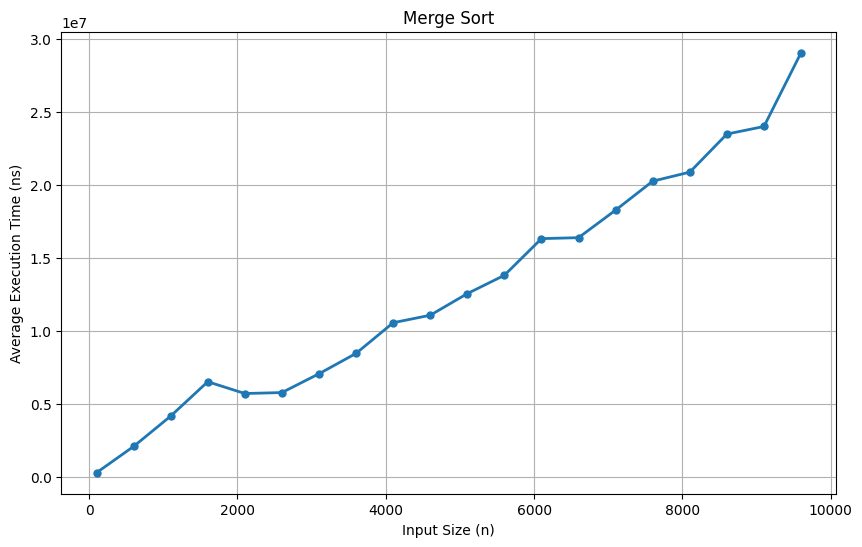

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    avg_times,
    marker='o',
    linewidth=2,
    markersize=5
)

plt.title("Merge Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Execution Time (ns)")
plt.grid(True)

plt.show()